# Exercises for Section 2.5 Multiple continuous random variables

This notebook contains the exercises from [Section 2.5 Multiple continuous random variables](https://minireference.com/static/excerpts/noBSstats_part1_preview.pdf#page=68) of the **No Bullshit Guide to Statistics**.

### Notebooks setup

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Figures setup
sns.set_theme(
    context="paper",
    style="whitegrid",
    palette="colorblind",
    rc={'figure.figsize': (5,3)},
)

%config InlineBackend.figure_format = 'retina'

In [3]:
# Simple float __repr__
import numpy as np
if int(np.__version__.split(".")[0]) >= 2:
    np.set_printoptions(legacy='1.25')

## Exercies

### E2.37



In [4]:
# @studentprompt


In [5]:
# @solution


### E2.38



In [6]:
# @studentprompt


In [7]:
# @solution


### E2.39



In [8]:
# @studentprompt


In [9]:
# @solution


### E2.40



In [10]:
# @studentprompt

from scipy.stats import multivariate_normal

In [11]:
import pandas as pd
students = pd.read_csv("datasets/students.csv")
students["effort"].mean(), students["score"].mean()


(8.904666666666666, 72.58)

In [12]:
students["effort"].std(), students["score"].std()


(1.9481561490169061, 9.979278531036199)

In [13]:
students[["effort","score"]].corr()

,effort,score
effort,1.000000,0.879438
score,0.879438,1.000000


In [14]:
# @solution
# a) Build the computer model
from scipy.stats import multivariate_normal

# Model parameters
muX, muY, sigmaX, sigmaY, rho = 8, 6, 2, 3, 0.9
# Package model parameters as a mean vector and covariance matrix
mu = [muX, muY]
Sigma = [[         sigmaX**2,     rho*sigmaX*sigmaY ],
         [ rho*sigmaX*sigmaY,             sigmaY**2 ]]

# Multivariate normal
rvXY = multivariate_normal(mu, Sigma)

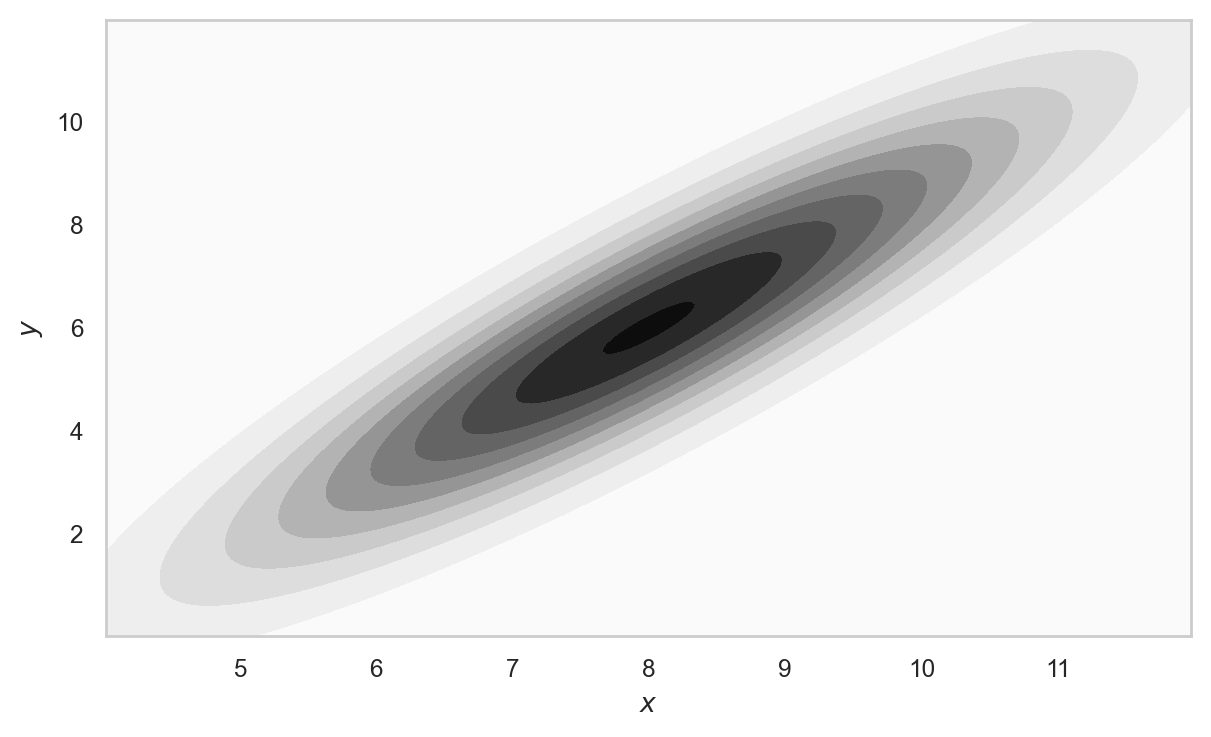

In [15]:
# @solution
# b) Plot the joint PDF f_XY
from ministats import plot_joint_pdf_contourf
xlims = [4, 12]
ylims = [0, 12]
plot_joint_pdf_contourf(rvXY, xlims=xlims, ylims=ylims);

In [16]:
# @solution
# c) Calculate the covariance Cov(X,Y)
rvXY.cov

array([[4. , 5.4],
       [5.4, 9. ]])

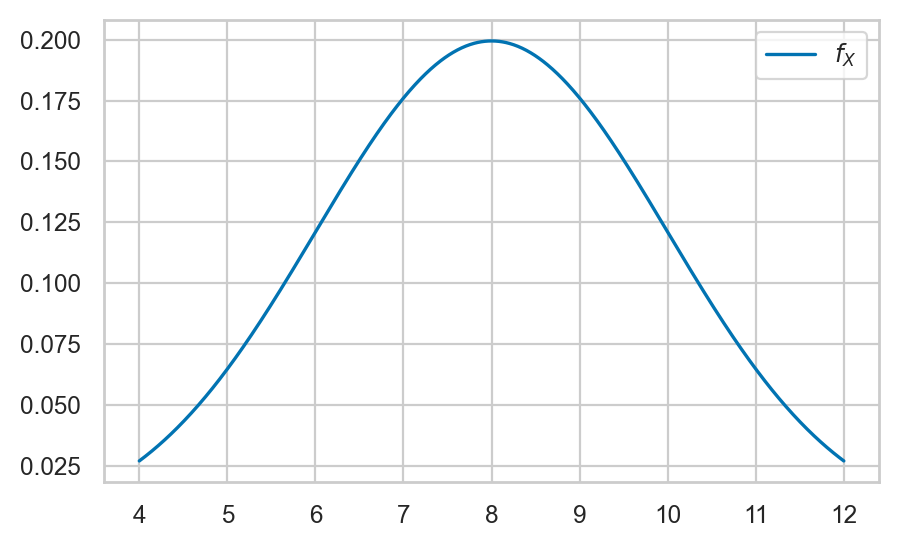

In [17]:
# @solution
# d) Plot the marginal f_X(x)
rvX = rvXY.marginal(dimensions=[0])

xs = np.linspace(4, 12, 1000)
fXs = rvX.pdf(xs)
sns.lineplot(x=xs, y=fXs, label="$f_X$");

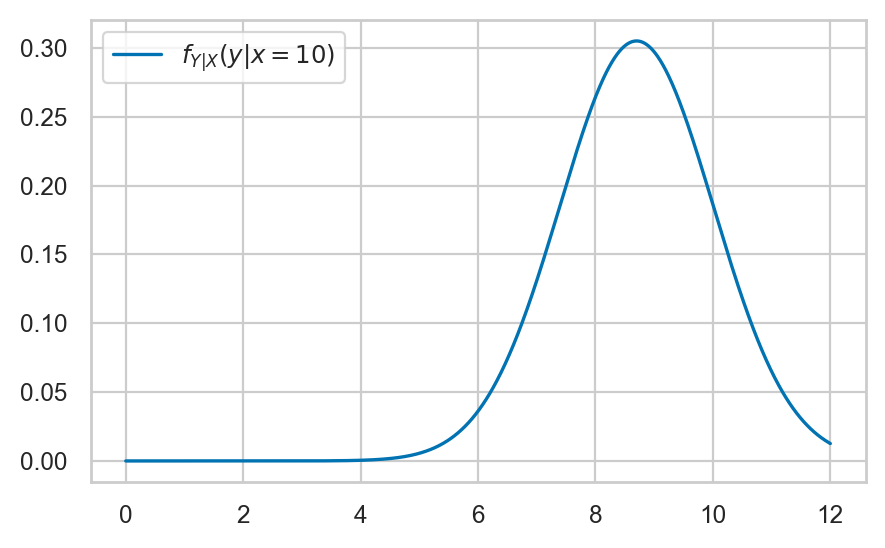

In [22]:
# @solution
# e) Plot the conditional f_{Y|X}(y|x=10)
from scipy.integrate import quad

def fYgivenX(y, x_a):
    """
    Compute the conditional distribtion f_Y|X(y|x=x_a).
    """
    rvX = rvXY.marginal(dimensions=[0])
    return rvXY.pdf([x_a,y]) / rvX.pdf(x_a)

ys = np.linspace(0, 12, 1000)
fYgivenX10s = [fYgivenX(y,x_a=10) for y in ys]
sns.lineplot(x=ys, y=fYgivenX10s, label="$f_{Y|X}(y|x=10)$");

f_Y|X(y|x=10) = 𝒩( 8.7 , 1.31 )


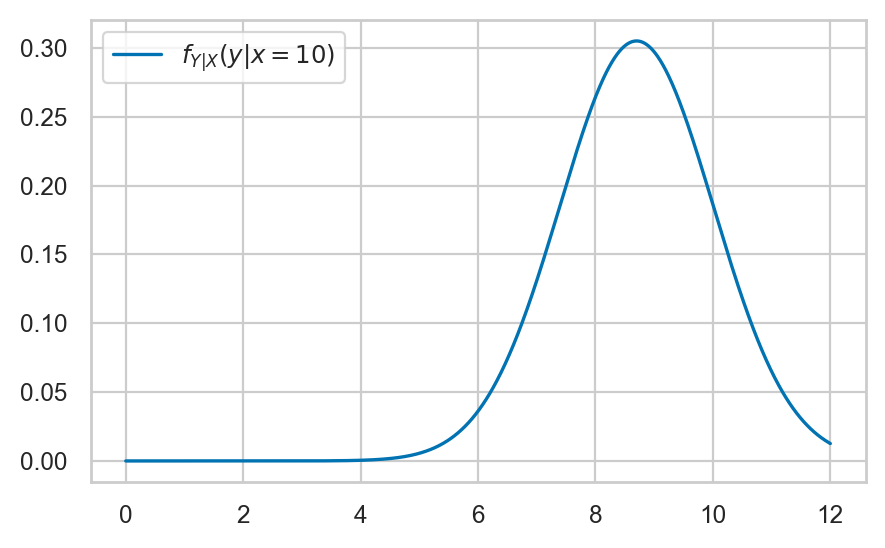

In [23]:
# @solution
# e) Calculate the conditional f_{Y|X}(y|x=10) using the formula
from scipy.stats import norm

# Parameters of fYgivenX10
muYgivenX10 = muY + rho*sigmaY/sigmaX*(10 - muX)
sigmaYgivenX = 3 * np.sqrt(1 - 0.9**2)
print("f_Y|X(y|x=10) = 𝒩(", muYgivenX10, ",", round(sigmaYgivenX,2), ")")

# Compute model for f_Y|X(y|x=10)
rvYgivenX10 = norm(muYgivenX10, sigmaYgivenX)

ys = np.linspace(0, 12, 1000)
sns.lineplot(x=ys, y=rvYgivenX10.pdf(ys), label="$f_{Y|X}(y|x=10)$");

### E2.41



In [20]:
# @studentprompt


In [21]:
# @solution
